# NBA MVP — Causal Effect of PER on Vote Share

**Course:** Foundations of Data Science  
**Group:** Tyler Song, Hyeonung Cho

**Question.** How does a player's Player Efficiency Rating (PER) affect his MVP vote share in a given NBA season?

**Causal model.** Treatment: PER. Outcome: MVP vote share. Confounder: Usage Rate. Adjustment set: `{Usage Rate}`.

```
   PER ────────► MVP share
    ▲              ▲
    │              │
    └── Usage Rate ┘
```

Conditioning on Usage Rate blocks the back-door path `PER ← Usage Rate → MVP share`, so the coefficient on PER is interpretable as its direct effect under the assumed DAG.

## 1. Setup

In [10]:
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")

ROOT = Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"
for d in (DATA_RAW, DATA_PROCESSED, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET = "sumitrodatta/nba-aba-baa-stats"
ADVANCED_CSV = "Advanced.csv"
AWARD_SHARES_CSV = "Player Award Shares.csv"
SEASON_MIN = 1980  # 3-point era onward

## 2. Download data from Kaggle

Two paths:
1. **Kaggle CLI configured** (`~/.kaggle/kaggle.json` exists) — the cell below downloads automatically.
2. **Manual** — download from https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats and drop `Advanced.csv` and `Player Award Shares.csv` into `data/raw/`.

Setting up the CLI:
```bash
pip install kaggle
# Create token at https://www.kaggle.com/settings -> 'Create New Token'
mv ~/Downloads/kaggle.json ~/.kaggle/kaggle.json
chmod 600 ~/.kaggle/kaggle.json
```

In [12]:
def have_kaggle_cli() -> bool:
    return shutil.which("kaggle") is not None and (Path.home() / ".kaggle" / "kaggle.json").exists()

def files_present() -> bool:
    return (DATA_RAW / ADVANCED_CSV).exists() and (DATA_RAW / AWARD_SHARES_CSV).exists()

if files_present():
    print(f"Files already in {DATA_RAW}. Skipping download.")
elif have_kaggle_cli():
    print(f"Downloading {KAGGLE_DATASET} -> {DATA_RAW}")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET, "-p", str(DATA_RAW), "--unzip"],
        check=True,
    )
    print("Done.")
else:
    print(
        "Kaggle CLI not configured. Either set up credentials (see markdown above)\n"
        f"or manually drop {ADVANCED_CSV} and {AWARD_SHARES_CSV} into {DATA_RAW}/",
        file=sys.stderr,
    )

assert files_present(), f"Missing CSVs in {DATA_RAW}. See instructions above."

Files already in c:\Personal\nba-mvp-analysis\data\raw. Skipping download.


## 3. Build the analysis dataset

Per proposal feedback: only players who actually received MVP votes are kept — vote share is structurally zero for everyone else and including them would dominate the response.

For traded players, the season-total row (coded `2TM`, `3TM`, etc. in this dataset) is used so PER and Usage Rate reflect the full season MVP voting was based on.

In [13]:
def load_advanced() -> pd.DataFrame:
    df = pd.read_csv(DATA_RAW / ADVANCED_CSV)
    df = df[df["lg"] == "NBA"].copy()
    # Traded mid-season -> one row per team plus a season-total row coded
    # "2TM", "3TM", "4TM", "5TM". MVP voting reflects the full season, so prefer
    # the season-total row when present, otherwise the single team row.
    is_total = df["team"].str.match(r"^\dTM$", na=False)
    counts = df.groupby(["player_id", "season"])["player_id"].transform("size")
    df = df[(counts == 1) | is_total]
    return df[["player_id", "player", "season", "team", "lg",
               "g", "mp", "per", "usg_percent"]].copy()

def load_mvp_shares() -> pd.DataFrame:
    df = pd.read_csv(DATA_RAW / AWARD_SHARES_CSV)
    df = df[df["award"].str.lower() == "nba mvp"].copy()
    return df[["player_id", "season", "player", "share", "winner"]].rename(
        columns={"share": "mvp_share"}
    )

adv = load_advanced()
mvp = load_mvp_shares()

df = mvp.merge(adv.drop(columns=["player"]), on=["player_id", "season"], how="inner")
df = df[df["season"] >= SEASON_MIN].copy()
df = df.dropna(subset=["per", "usg_percent", "mvp_share"])
df = df[(df["mvp_share"] > 0) & (df["mvp_share"] < 1)].copy()
df = df.sort_values(["season", "mvp_share"], ascending=[True, False]).reset_index(drop=True)

df.to_csv(DATA_PROCESSED / "mvp_per_usg.csv", index=False)
print(f"Built {len(df):,} rows ({df['season'].min()}–{df['season'].max()})")
df.head(10)

Built 730 rows (1980–2025)


,player_id,season,player,mvp_share,winner,team,lg,g,mp,per,usg_percent
0,abdulka01,1980,Kareem Abdul-Jabbar,0.665,True,LAL,NBA,82,3143.0,25.3,24.1
1,ervinju01,1980,Julius Erving,0.143,False,PHI,NBA,78,2812.0,25.4,30.3
2,gervige01,1980,George Gervin,0.086,False,SAS,NBA,78,2934.0,24.0,31.7
3,birdla01,1980,Larry Bird,0.068,False,BOS,NBA,82,2955.0,20.5,25.3
4,architi01,1980,Tiny Archibald,0.009,False,BOS,NBA,80,2864.0,15.3,17.0
5,johnsde01,1980,Dennis Johnson,0.009,False,SEA,NBA,81,2937.0,15.9,24.2
6,roundda01,1980,Dan Roundfield,0.009,False,ATL,NBA,81,2588.0,19.7,22.8
7,willigu01,1980,Gus Williams,0.007,False,SEA,NBA,82,2969.0,20.6,25.2
8,malonmo01,1980,Moses Malone,0.005,False,HOU,NBA,82,3140.0,24.1,27.6
9,ervinju01,1981,Julius Erving,0.658,True,PHI,NBA,82,2874.0,25.1,28.4


## 4. Summary stats

In [14]:
print(f"Rows: {len(df):,}")
print(f"Seasons: {df['season'].min()}–{df['season'].max()}")
print(f"Unique players: {df['player_id'].nunique():,}")
print(f"MVP winners in window: {df['winner'].sum()}")
df[["per", "usg_percent", "mvp_share"]].describe().round(3)

Rows: 730
Seasons: 1980–2025
Unique players: 209
MVP winners in window: 45


,per,usg_percent,mvp_share
count,730.000,730.000,730.000
mean,22.725,26.918,0.160
std,3.829,5.010,0.261
min,10.100,7.100,0.001
25%,20.100,23.900,0.004
50%,22.700,27.200,0.022
75%,25.100,30.300,0.197
max,32.800,41.700,0.998


In [15]:
# Top 10 vote shares ever (in window)
df.nlargest(10, "mvp_share")[["season", "player", "per", "usg_percent", "mvp_share"]]

,season,player,per,usg_percent,mvp_share
371,2000,Shaquille O'Neal,30.6,31.2,0.998
567,2013,LeBron James,31.6,30.2,0.998
435,2004,Kevin Garnett,29.4,29.6,0.991
294,1996,Michael Jordan,29.4,33.3,0.986
583,2014,Kevin Durant,29.8,33.0,0.986
126,1986,Larry Bird,25.6,27.6,0.981
524,2010,LeBron James,31.1,33.5,0.980
103,1985,Larry Bird,26.5,28.5,0.978
539,2011,Derrick Rose,23.5,32.2,0.977
512,2009,LeBron James,31.7,33.8,0.969


## 5. Figures

### 5a. Outcome distribution

Vote share is heavily right-skewed — most vote-getters poll under 5%, a handful dominate.

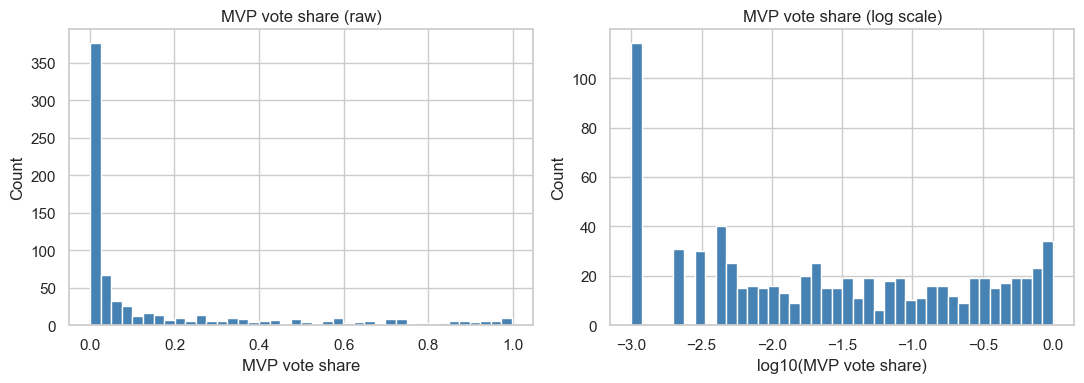

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df["mvp_share"], bins=40, color="steelblue", edgecolor="white")
ax[0].set(xlabel="MVP vote share", ylabel="Count", title="MVP vote share (raw)")
ax[1].hist(np.log10(df["mvp_share"]), bins=40, color="steelblue", edgecolor="white")
ax[1].set(xlabel="log10(MVP vote share)", ylabel="Count", title="MVP vote share (log scale)")
fig.tight_layout()
fig.savefig(FIGURES / "01_outcome_distribution.png", dpi=150)
plt.show()

### 5b. Treatment vs outcome

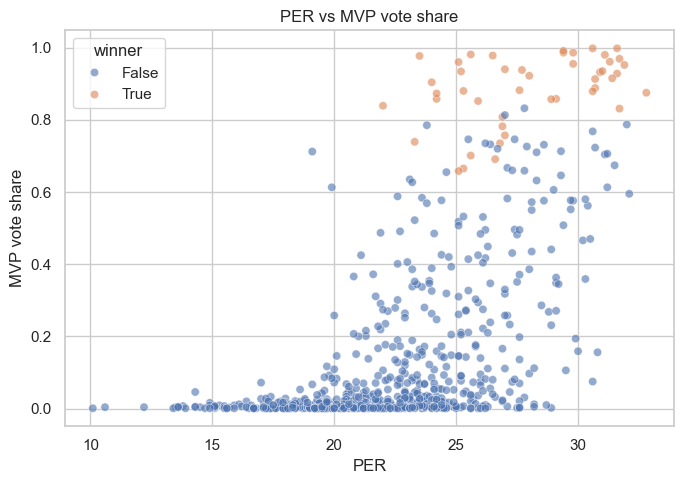

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="per", y="mvp_share", hue="winner", alpha=0.6, ax=ax)
ax.set(xlabel="PER", ylabel="MVP vote share", title="PER vs MVP vote share")
fig.tight_layout()
fig.savefig(FIGURES / "02_per_vs_share.png", dpi=150)
plt.show()

### 5c. Confounder check

If Usage Rate is a true confounder it should associate with both the outcome (MVP share) **and** the treatment (PER). Both panels below should show clear positive trends.

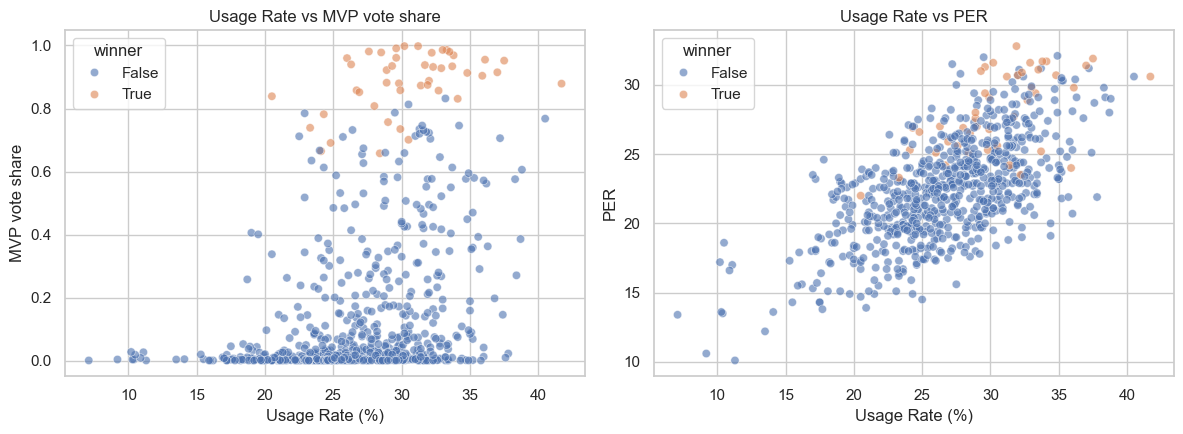

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=df, x="usg_percent", y="mvp_share", hue="winner", alpha=0.6, ax=ax[0])
ax[0].set(xlabel="Usage Rate (%)", ylabel="MVP vote share", title="Usage Rate vs MVP vote share")
sns.scatterplot(data=df, x="usg_percent", y="per", hue="winner", alpha=0.6, ax=ax[1])
ax[1].set(xlabel="Usage Rate (%)", ylabel="PER", title="Usage Rate vs PER")
fig.tight_layout()
fig.savefig(FIGURES / "03_usage_confounder.png", dpi=150)
plt.show()

### 5d. Correlation matrix

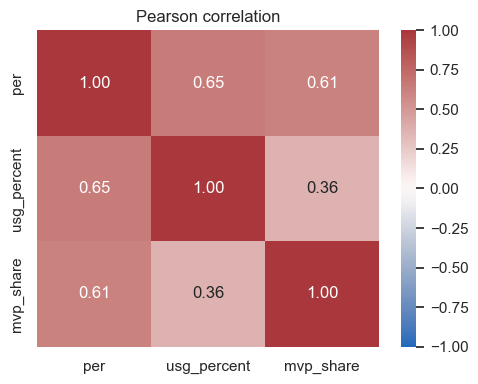

In [19]:
corr = df[["per", "usg_percent", "mvp_share"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation")
fig.tight_layout()
fig.savefig(FIGURES / "04_correlation.png", dpi=150)
plt.show()

### 5e. Vote-getters per season

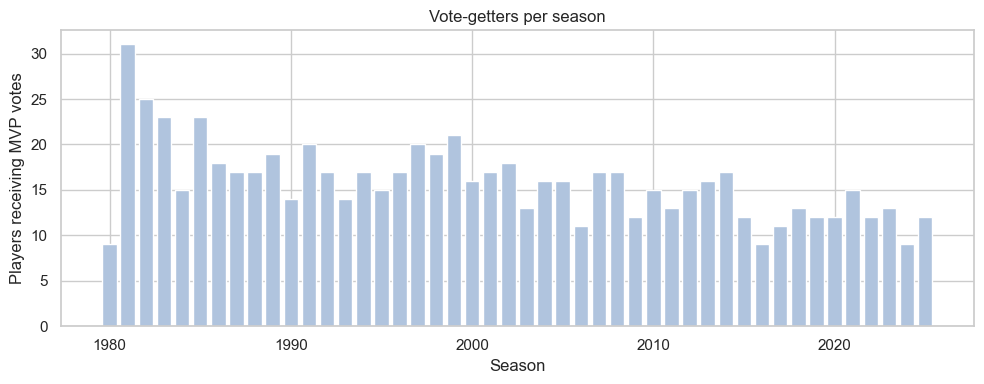

In [20]:
by_season = df.groupby("season").size().reset_index(name="n")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_season["season"], by_season["n"], color="lightsteelblue")
ax.set(xlabel="Season", ylabel="Players receiving MVP votes", title="Vote-getters per season")
fig.tight_layout()
fig.savefig(FIGURES / "05_per_season.png", dpi=150)
plt.show()

## 6. Modeling framework (not yet fit)

Two model options. Predictors are **standardised** (mean 0, SD 1) so the proposal's `Normal(0, 0.5)` priors are on a sensible scale.

### Option A — Beta regression (proposal's choice)

$$y_i \sim \text{Beta}(\mu_i \phi,\, (1 - \mu_i)\phi)$$
$$\text{logit}(\mu_i) = \alpha + \beta_P \cdot \text{PER}_i + \beta_U \cdot \text{USG}_i$$
$$\alpha,\, \beta_P,\, \beta_U \sim \mathcal{N}(0,\, 0.5),\quad \phi \sim \text{Exponential}(1)$$

Note: the proposal wrote `μᵢ = α + β_P·P + β_U·U` directly. With a Beta likelihood `μ` must be in (0,1), so a `logit` link is added — this is the standard fix and avoids divergences.

### Option B — LogitNormal (grader's fallback)

$$\text{logit}(y_i) \sim \mathcal{N}(\alpha + \beta_P \cdot \text{PER}_i + \beta_U \cdot \text{USG}_i,\, \sigma)$$

Easier to fit when Beta gives divergences; loses Beta's natural mean–variance coupling.

### Sampler

After filtering to vote-getters the dataset is in the low hundreds of rows — NUTS/HMC should sample in seconds. The grader's concern about HMC scale applies only if the unfiltered dataset is ever used.

In [21]:
# Standardise predictors — do this regardless of which model you fit
df_std = df.copy()
for col in ("per", "usg_percent"):
    df_std[f"{col}_z"] = (df_std[col] - df_std[col].mean()) / df_std[col].std()
df_std[["per", "per_z", "usg_percent", "usg_percent_z", "mvp_share"]].describe().round(3)

,per,per_z,usg_percent,usg_percent_z,mvp_share
count,730.000,730.000,730.000,730.000,730.000
mean,22.725,0.000,26.918,-0.000,0.160
std,3.829,1.000,5.010,1.000,0.261
min,10.100,-3.297,7.100,-3.955,0.001
25%,20.100,-0.685,23.900,-0.602,0.004
50%,22.700,-0.006,27.200,0.056,0.022
75%,25.100,0.620,30.300,0.675,0.197
max,32.800,2.631,41.700,2.950,0.998


In [26]:
#Beta regression — uncomment to fit (requires `pip install pymc arviz`)

import pymc as pm
import arviz as az

with pm.Model() as beta_model:
    alpha = pm.Normal("alpha", -2, 1)
    beta_P = pm.Normal("beta_P", 0, 1)
    beta_U = pm.Normal("beta_U", 0, 1)
    phi = pm.Exponential("phi", 0.1)

    eta = alpha + beta_P * df_std["per_z"].values + beta_U * df_std["usg_percent_z"].values
    mu = pm.Deterministic("mu", pm.math.sigmoid(eta))

    pm.Beta("y", alpha=mu * phi, beta=(1 - mu) * phi, observed=df_std["mvp_share"].values)
    idata_beta = pm.sample(2000, tune=2000, target_accept=0.95, chains=4, random_seed=42, nuts_sampler="nutpie")

az.summary(idata_beta, var_names=["alpha", "beta_P", "beta_U", "phi"])

Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.49,7
,4000,0,0.47,15
,4000,0,0.45,15
,4000,0,0.49,7


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.599,0.052,-1.701,-1.505,0.001,0.001,4609.0,4962.0,1.0
beta_P,0.786,0.057,0.680,0.896,0.001,0.001,3739.0,3825.0,1.0
beta_U,-0.042,0.052,-0.139,0.058,0.001,0.001,5044.0,5304.0,1.0
phi,2.274,0.129,2.035,2.516,0.002,0.001,4359.0,5216.0,1.0


In [ ]:
# LogitNormal alternative — uncomment to fit
#
# import pymc as pm
# import arviz as az
#
# y_logit = np.log(df_std["mvp_share"] / (1 - df_std["mvp_share"])).values
# with pm.Model() as ln_model:
#     alpha = pm.Normal("alpha", 0, 1)
#     beta_P = pm.Normal("beta_P", 0, 0.5)
#     beta_U = pm.Normal("beta_U", 0, 0.5)
#     sigma = pm.Exponential("sigma", 1.0)
#
#     mu = alpha + beta_P * df_std["per_z"].values + beta_U * df_std["usg_percent_z"].values
#     pm.Normal("y", mu=mu, sigma=sigma, observed=y_logit)
#     idata_ln = pm.sample(1000, tune=1000, chains=4, random_seed=42)
#
# az.summary(idata_ln, var_names=["alpha", "beta_P", "beta_U", "sigma"])

## 7. Suggestions / next steps

- **Posterior predictive checks.** Simulate vote shares from the fit and compare to observed — Beta's mean/variance coupling can distort the right tail.
- **Era effects.** PER inflation has shifted over decades; if the 3-variable budget allows, consider a per-season intercept `alpha[season]` as a hierarchical extension.
- **Sensitivity.** Refit excluding modern superstar seasons (Jordan, LeBron, Jokic-era) to check whether the PER coefficient is driven by a handful of cases.
- **Sampler fallback.** If NUTS is slow or diverges, try `pm.fit()` (ADVI) for a fast approximation, or `pm.find_MAP()` for a point estimate sanity check.